In [1]:
import pandas as pd

eventlog = pd.read_csv(
    "../../data/processed/CTB/s6_eventlog_with_performance_targets.csv"
)

eventlog["start:timestamp"] = pd.to_datetime(
    eventlog["start:timestamp"]
)

# Gate-In Events extrahieren
gatein_features = (
    eventlog[
        eventlog["concept:name"] == "Gate In"
    ][
        [
            "case:concept:name",
            "start:timestamp"
        ]
    ]
    .copy()
)

# Stunde des Tages
gatein_features["gatein_hour"] = (
    gatein_features["start:timestamp"]
    .dt.hour
)

# Wochentag als Name
gatein_features["gatein_weekday"] = (
    gatein_features["start:timestamp"]
    .dt.day_name()
)

# optional zusätzlich numerisch
gatein_features["gatein_weekday_num"] = (
    gatein_features["start:timestamp"]
    .dt.weekday
)

# auf alle Events des Cases mappen
eventlog = eventlog.merge(
    gatein_features[
        [
            "case:concept:name",
            "gatein_hour",
            "gatein_weekday",
            "gatein_weekday_num"
        ]
    ],
    on="case:concept:name",
    how="left"
)

eventlog.head()

,case:concept:name,concept:name,org:resource,enabled:timestamp,start:timestamp,time:timestamp,process_flow_type,n_containers,n_stops,n_deliveries,...,target_utilization,target_demand,target_utilization_bin,target_demand_bin,waiting_time,service_time,turnaround_time,gatein_hour,gatein_weekday,gatein_weekday_num
0,TP_14848272603,Gate In,Res.GateIn,2026-03-02 07:03:00,2026-03-02 07:06:00,2026-03-02 07:06:00,delivery,1,1,1,...,0.7600,9.9,very_high,very_high,3.0,0.0,12.0,7,Monday,0
1,TP_14848272603,RMG_delivery,T22,2026-03-02 07:10:00,2026-03-02 07:13:00,2026-03-02 07:15:00,delivery,1,1,1,...,0.7600,9.9,very_high,very_high,3.0,2.0,12.0,7,Monday,0
2,TP_14848272603,Gate Out,Res.GateOut,2026-03-02 07:20:00,2026-03-02 07:18:00,2026-03-02 07:18:00,delivery,1,1,1,...,0.7600,9.9,very_high,very_high,-2.0,0.0,12.0,7,Monday,0
3,TP_14848282603,Gate In,Res.GateIn,2026-03-02 06:58:00,2026-03-02 07:06:00,2026-03-02 07:06:00,receive,1,1,0,...,0.7622,8.6,very_high,very_high,8.0,0.0,37.0,7,Monday,0
4,TP_14848282603,RMG_receive,T18,2026-03-02 07:10:00,2026-03-02 07:12:00,2026-03-02 07:18:00,receive,1,1,0,...,0.7622,8.6,very_high,very_high,2.0,6.0,37.0,7,Monday,0


In [5]:
features = [
    "target_utilization",
    "target_demand",
    "visit_complexity",
    "n_containers",
    "n_receives",
    "n_deliveries",
    "has_hazardous",
    #"process_flow_type",
    "full_ratio",
    "gate_demand",
    "gate_utilization",
    "gatein_hour",
    "gatein_weekday_num"
]

rmg = eventlog[
    eventlog["concept:name"].isin(
        [
            "RMG_receive",
            "RMG_delivery",
            "RMG_mixed"
        ]
    )
].copy()

X = rmg[features]

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import pandas as pd

targets = [
    "service_time",
    "waiting_time",
    "turnaround_time"
]

results = {}

for target in targets:

    y = rmg[target]

    rf = RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X, y)

    pred = rf.predict(X)

    r2 = r2_score(y, pred)

    importance = (
        pd.Series(
            rf.feature_importances_,
            index=X.columns
        )
        .sort_values(ascending=False)
    )

    results[target] = {
        "r2": r2,
        "importance": importance
    }

    print("=" * 60)
    print(f"TARGET: {target}")
    print(f"R²: {r2:.4f}")
    print()
    print(importance)
    print()

TARGET: service_time
R²: 0.8932

target_utilization    0.219405
gate_demand           0.201513
target_demand         0.192147
gate_utilization      0.141943
gatein_hour           0.072318
visit_complexity      0.057680
gatein_weekday_num    0.041794
n_receives            0.027453
n_containers          0.015304
full_ratio            0.015019
n_deliveries          0.008687
has_hazardous         0.006735
dtype: float64

TARGET: waiting_time
R²: 0.9436

target_utilization    0.271127
target_demand         0.196920
gate_utilization      0.167164
gate_demand           0.164088
gatein_hour           0.076039
gatein_weekday_num    0.052378
visit_complexity      0.033090
full_ratio            0.010571
n_receives            0.010209
n_deliveries          0.008384
n_containers          0.007282
has_hazardous         0.002748
dtype: float64

TARGET: turnaround_time
R²: 0.9135

target_utilization    0.219093
gate_demand           0.196186
target_demand         0.179961
gate_utilization      0.13862

In [7]:
pd.DataFrame(
    {
        target: {
            "R2": results[target]["r2"]
        }
        for target in results
    }
).T.sort_values("R2", ascending=False)

,R2
waiting_time,0.943577
turnaround_time,0.913510
service_time,0.893186


In [8]:
#EVALUATOON ON TRAIN SPLIT
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import pandas as pd

targets = [
    "service_time",
    "waiting_time",
    "turnaround_time"
]

for target in targets:

    print("\n" + "=" * 60)
    print(f"TARGET: {target}")
    print("=" * 60)

    y = rmg[target]

    rf = RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )
    
    rf.fit(X, y)

    importance = pd.Series(
        rf.feature_importances_,
        index=X.columns
    ).sort_values(
        ascending=False
    )

    print("\nFeature Importances:")
    print(importance)

    pred = rf.predict(X)

    print("\nR² Score:")
    print(
        r2_score(
            y,
            pred
        )
    )


TARGET: service_time

Feature Importances:
target_utilization    0.219405
gate_demand           0.201513
target_demand         0.192147
gate_utilization      0.141943
gatein_hour           0.072318
visit_complexity      0.057680
gatein_weekday_num    0.041794
n_receives            0.027453
n_containers          0.015304
full_ratio            0.015019
n_deliveries          0.008687
has_hazardous         0.006735
dtype: float64

R² Score:
0.8931859763083365

TARGET: waiting_time

Feature Importances:
target_utilization    0.271127
target_demand         0.196920
gate_utilization      0.167164
gate_demand           0.164088
gatein_hour           0.076039
gatein_weekday_num    0.052378
visit_complexity      0.033090
full_ratio            0.010571
n_receives            0.010209
n_deliveries          0.008384
n_containers          0.007282
has_hazardous         0.002748
dtype: float64

R² Score:
0.9435770613127925

TARGET: turnaround_time

Feature Importances:
target_utilization    0.219093


In [9]:
# EVALUATION ON TEST SPLIT
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import pandas as pd

targets = [
    "service_time",
    "waiting_time",
    "turnaround_time"
]

for target in targets:

    print("\n" + "=" * 60)
    print(f"TARGET: {target}")
    print("=" * 60)

    y = rmg[target]

    rf = RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    )
    
    from sklearn.model_selection import train_test_split

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    rf.fit(X_train, y_train)

    importance = pd.Series(
        rf.feature_importances_,
        index=X.columns
    ).sort_values(
        ascending=False
    )

    print("\nFeature Importances:")
    print(importance)

    pred = rf.predict(X_test)


    print("\nR² Score:")
    print(
        r2_score(
            y_test,
            pred
        )
    )


TARGET: service_time

Feature Importances:
target_utilization    0.216046
gate_demand           0.202852
target_demand         0.193537
gate_utilization      0.138623
gatein_hour           0.073669
visit_complexity      0.058314
gatein_weekday_num    0.041079
n_receives            0.026674
n_containers          0.016097
full_ratio            0.015967
n_deliveries          0.010127
has_hazardous         0.007014
dtype: float64

R² Score:
0.23296436721670022

TARGET: waiting_time

Feature Importances:
target_utilization    0.266908
target_demand         0.196426
gate_demand           0.165532
gate_utilization      0.162720
gatein_hour           0.076857
gatein_weekday_num    0.054126
visit_complexity      0.035492
full_ratio            0.011290
n_receives            0.010929
n_deliveries          0.009251
n_containers          0.007725
has_hazardous         0.002744
dtype: float64

R² Score:
0.5229228666858026

TARGET: turnaround_time

Feature Importances:
target_utilization    0.212185

In [10]:
rmg[features].nunique()

target_utilization    6031
target_demand          968
visit_complexity        25
n_containers             5
n_receives               6
n_deliveries             6
has_hazardous            2
full_ratio              13
gate_demand           9084
gate_utilization      1515
gatein_hour             24
gatein_weekday_num       6
dtype: int64

In [11]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print(scores)
print(scores.mean())


[-0.26332975  0.07057939 -0.67258623  0.06253745 -0.00681008]
-0.1619218447184757


In [12]:
#PERMUTATION IMPORTANCE 
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1
)

pd.Series(
    perm.importances_mean,
    index=X.columns
).sort_values(ascending=False)

n_containers          0.362660
gate_demand           0.328316
gatein_hour           0.267477
gate_utilization      0.234767
gatein_weekday_num    0.222525
target_demand         0.218593
target_utilization    0.178902
visit_complexity      0.118777
n_deliveries          0.075487
n_receives            0.074679
full_ratio            0.010321
has_hazardous        -0.001116
dtype: float64

In [13]:
rmg["service_time"].describe()


count    65996.000000
mean        11.654206
std         11.308462
min          1.000000
25%          5.000000
50%          8.000000
75%         14.000000
max        234.000000
Name: service_time, dtype: float64

<Axes: >

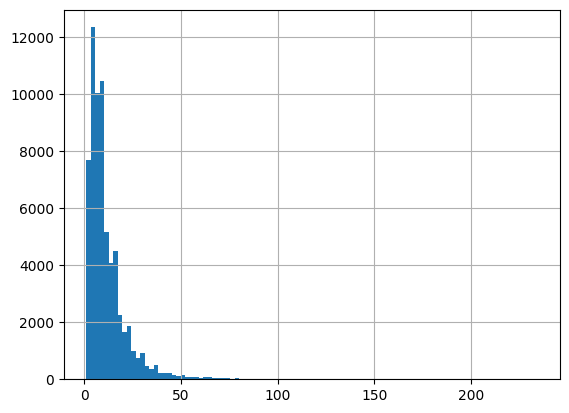

In [14]:
rmg["service_time"].hist(bins=100)